In [1]:
import pandas as pd
import numpy as np
import xarray as xr
import torch
import matplotlib.pyplot as plt

from models import FluxNet
from models import compute_divergence_field

device = "cuda" if torch.cuda.is_available() else "cpu"

# Load all data

In [2]:
data = torch.load("data/flux_tensor.pt", weights_only = False)

# Load trained model

In [4]:
# Initialise
model = FluxNet().to(device)
# Load trained weights
model.load_state_dict(torch.load("fluxnet_trained_on_all_data/fluxnet_full_model.pth", map_location = device))
model.eval()

/tmp/ipykernel_303136/2008024611.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("fluxnet_trained_on_all_data/fluxnet_full_model.pth", m

FluxNet(
  (inp): Sequential(
    (0): Linear(in_features=2, out_features=256, bias=True)
    (1): SiLU()
  )
  (trunk): ModuleList(
    (0-5): 6 x _ResBlock(
      (lin1): Linear(in_features=256, out_features=256, bias=True)
      (lin2): Linear(in_features=256, out_features=256, bias=True)
      (act): SiLU()
    )
  )
  (head_df_psi): Linear(in_features=256, out_features=1, bias=True)
  (head_cf_phi): Linear(in_features=256, out_features=1, bias=True)
)

# Load bounds for normalisation

In [5]:
from regions import ROSS_BOUNDS

x_min = ROSS_BOUNDS["x_min"]
x_max = ROSS_BOUNDS["x_max"]
y_min = ROSS_BOUNDS["y_min"]
y_max = ROSS_BOUNDS["y_max"]

In [6]:
target_grid_mask = xr.load_dataset("data/target_grid_mask.nc")

# make meshgrid
X, Y = xr.broadcast(target_grid_mask.x, target_grid_mask.y)

X_long = X.values.flatten()
Y_long = Y.values.flatten()

# NOTE: Normalise to [0, 1] as model input
X_long = (X_long - x_min) / (x_max - x_min)
Y_long = (Y_long - y_min) / (y_max - y_min)

XY_long_tensor = torch.cat((torch.tensor(X_long).unsqueeze(1), torch.tensor(Y_long).unsqueeze(1)), dim = 1)
print(XY_long_tensor.shape)
print(XY_long_tensor[0:5, :])

torch.Size([4000000, 2])
tensor([[2.5000e-04, 9.9975e-01],
        [2.5000e-04, 9.9925e-01],
        [2.5000e-04, 9.9875e-01],
        [2.5000e-04, 9.9825e-01],
        [2.5000e-04, 9.9775e-01]])


# Subset small area

In [28]:
range = 400
y_start_idx = 1500
y_end_idx = y_start_idx + range
x_start_idx = 1200
x_end_idx = x_start_idx + range

# range = 400
# y_start_idx = 700
# y_end_idx = y_start_idx + range
# x_start_idx = 500
#x_end_idx = x_start_idx + range

# Subset and downsample (500 m grid otherwise is to granular to see large-scale patterns)
# downsample_factor = 20 yields 20 x 20
downsample_factor = 30 # yields 14 x 14 (better to visually interpret)
X_zoom = X[y_start_idx : y_end_idx, x_start_idx : x_end_idx][::downsample_factor, ::downsample_factor]
print(X_zoom.shape)
Y_zoom = Y[y_start_idx : y_end_idx, x_start_idx : x_end_idx][::downsample_factor, ::downsample_factor]
print(Y_zoom.shape)

# Make long
X_zoom_long = X_zoom.values.flatten()
Y_zoom_long = Y_zoom.values.flatten()

# Normalise to [0, 1] as model input
X_zoom_norm = (X_zoom_long - x_min) / (x_max - x_min)
Y_zoom_norm = (Y_zoom_long - y_min) / (y_max - y_min)

# Make tensor
XY_zoom_tensor = torch.cat((torch.tensor(X_zoom_norm).unsqueeze(1), torch.tensor(Y_zoom_norm).unsqueeze(1)), dim = 1)
print(XY_zoom_tensor.shape)

# Make hr tensor for div plotting
downsample_factor_hr = 5
X_zoom_hr = X[y_start_idx : y_end_idx, x_start_idx : x_end_idx][::downsample_factor_hr, ::downsample_factor_hr]
Y_zoom_hr = Y[y_start_idx : y_end_idx, x_start_idx : x_end_idx][::downsample_factor_hr, ::downsample_factor_hr]
XY_zoom_tensor_hr = torch.cat((torch.tensor((X_zoom_hr.values.flatten() - x_min) / (x_max - x_min)).unsqueeze(1), torch.tensor((Y_zoom_hr.values.flatten() - y_min) / (y_max - y_min)).unsqueeze(1)), dim = 1).to(device)
print(XY_zoom_tensor_hr.shape)

(14, 14)
(14, 14)
torch.Size([196, 2])
torch.Size([6400, 2])


# Zoomed in location on modis

In [29]:
modis_ross = torch.load("data/modis/moa125_2014_hp1_v01_ross_with_grid_no_ocean.pt", weights_only = False)
modis_ross.shape

(3, 7999, 8000)

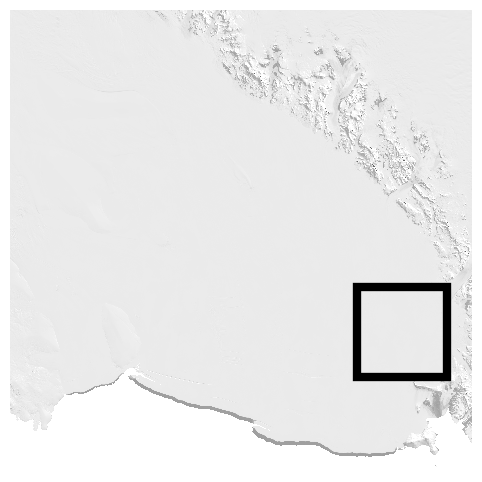

In [37]:
vis_again = True
from matplotlib.patches import Rectangle

# Only rerun if needed
if vis_again :
    fig, ax = plt.subplots(figsize = (8, 6))

    # 1) MODIS as background (draw first)
    ax.pcolormesh(
    modis_ross[0],
    modis_ross[1], 
    modis_ross[2],
    cmap = "gray",
    # softer greys
    vmin = -10_000, 
    vmax = 20_000,
    # as less saturated background
    alpha = 0.6,
    zorder = 0,
    )

    # 2) Rectangle showing zoom region (in the same x/y units as your plot)
    x0 = float(X_zoom_long.min())
    x1 = float(X_zoom_long.max())
    y0 = float(Y_zoom_long.min())
    y1 = float(Y_zoom_long.max())

    rect = Rectangle(
        (x0, y0),
        x1 - x0,
        y1 - y0,
        fill = False,
        linewidth = 6.0,
        edgecolor = "black",
        zorder = 5,
    )
    ax.add_patch(rect)
    ax.set_aspect("equal")
    ax.set_axis_off()

    fig.savefig("figures/modis_location_helmholtz.png", dpi = 300, bbox_inches = "tight", pad_inches = 0)
    plt.show()

In [30]:
print("Zoomed grid stats:")
print("X max:", X_zoom_long.max().item()) # - 50 k 200km span
print("X min:", X_zoom_long.min().item()) # - 250 k
print("Y max:", Y_zoom_long.max().item()) # - 650 k 200km span
print("Y min:", Y_zoom_long.min().item()) # - 850 k

Zoomed grid stats:
X max: 345250.0
X min: 150250.0
Y max: -1000250.0
Y min: -1195250.0


In [31]:
# Smaller version for quivers
XY_batch = XY_zoom_tensor.requires_grad_(True).to(device)

q_xy, df, cf = model(XY_batch, return_parts = True)

# div = compute_divergence_field(
#     mean_pred = q_xy, 
#     x_grad = XY_batch)

# HR version for smoother div field
XY_batch_hr = XY_zoom_tensor_hr.requires_grad_(True).to(device)

q_xy_hr, _, _ = model(XY_batch_hr, return_parts = True)

div_hr = compute_divergence_field(
    mean_pred = q_xy_hr, 
    x_grad = XY_batch_hr)

# q

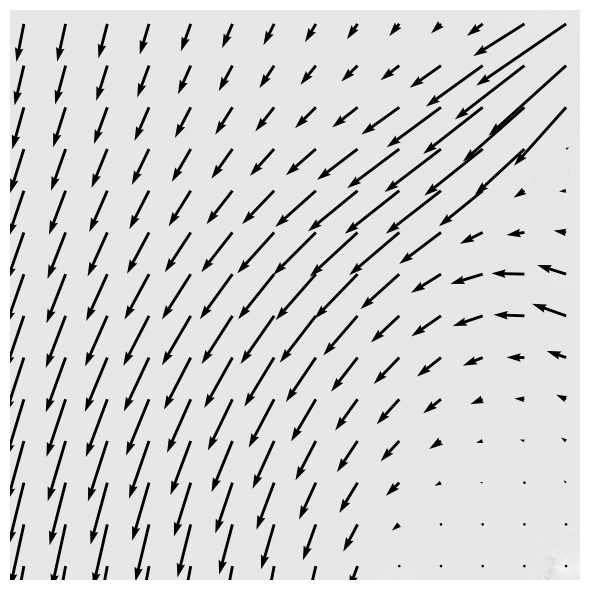

In [32]:
XY = XY_zoom_tensor.detach().cpu().numpy()
q = q_xy.detach().cpu().numpy()

x, y = XY[:, 0], XY[:, 1]
qx, qy = q[:, 0], q[:, 1]

X_modis_norm = (modis_ross[0] - x_min) / (x_max - x_min)
Y_modis_norm = (modis_ross[1] - y_min) / (y_max - y_min)

fig, ax = plt.subplots(figsize = (8, 6))

# 1) MODIS background

ax.pcolormesh(
    X_modis_norm,
    Y_modis_norm,
    modis_ross[2],
    cmap = "gray",
    vmin = -30_000,
    vmax = 30_000,
    alpha = 0.4,
    zorder = 0,
)

# 2) Quiver overlay
ax.quiver(
    x, y, qx, qy,
    # fixed scale & width
    scale = 24.0,
    width = 0.005,
    zorder = 2,)

# Cut off outside oflast vector
buffer = 0.005
ax.set_aspect("equal")
ax.set_xlim(x.min() - buffer, x.max() + buffer)
ax.set_ylim(y.min() - buffer, y.max() + buffer)
ax.set_axis_off()

fig.tight_layout()

fig.savefig("figures/q_helmholtz.png", dpi = 300, bbox_inches = "tight", pad_inches = 0)
plt.show()

# q_df

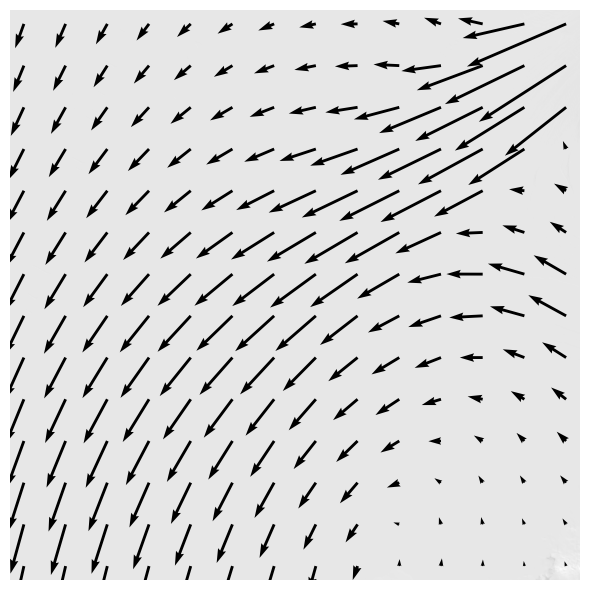

In [33]:
XY = XY_zoom_tensor.detach().cpu().numpy()
q_df = df.detach().cpu().numpy()

x, y = XY[:, 0], XY[:, 1]
q_df_x, q_df_y = q_df[:, 0], q_df[:, 1]

X_modis_norm = (modis_ross[0] - x_min) / (x_max - x_min)
Y_modis_norm = (modis_ross[1] - y_min) / (y_max - y_min)

fig, ax = plt.subplots(figsize = (8, 6))

# 1) MODIS background
ax.pcolormesh(
    X_modis_norm,
    Y_modis_norm,
    modis_ross[2],
    cmap = "gray",
    vmin = -30_000,
    vmax = 30_000,
    alpha = 0.4,
    zorder = 0,
)

# 2) Quiver overlay
ax.quiver(
    x, y, q_df_x, q_df_y,
    # fixed scale & width
    scale = 24.0,
    width = 0.005,
    zorder = 2)

# Cut off outside oflast vector
buffer = 0.005
ax.set_aspect("equal")
ax.set_xlim(x.min() - buffer, x.max() + buffer)
ax.set_ylim(y.min() - buffer, y.max() + buffer)
ax.set_axis_off()

fig.tight_layout()

fig.savefig("figures/q_df_helmholtz.png", dpi = 300, bbox_inches = "tight", pad_inches = 0)
plt.show()

# q_cf

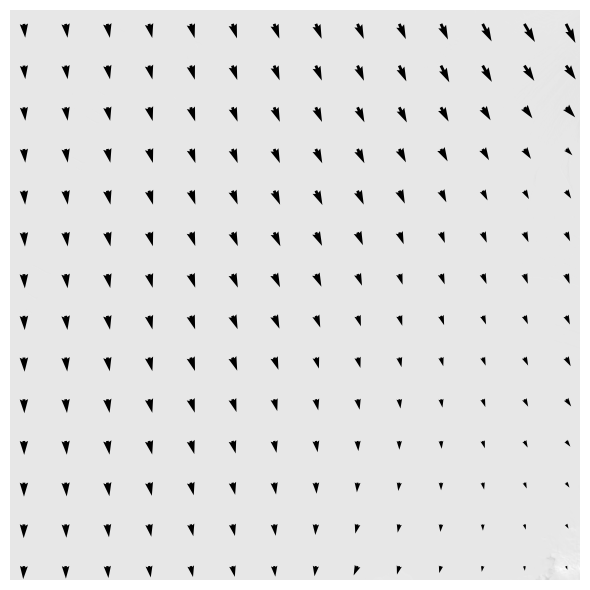

In [34]:
XY = XY_zoom_tensor.detach().cpu().numpy()
q_cf = cf.detach().cpu().numpy()

x, y = XY[:, 0], XY[:, 1]
q_cf_x, q_cf_y = q_cf[:, 0], q_cf[:, 1]

X_modis_norm = (modis_ross[0] - x_min) / (x_max - x_min)
Y_modis_norm = (modis_ross[1] - y_min) / (y_max - y_min)

fig, ax = plt.subplots(figsize = (8, 6))

# 1) MODIS background
ax.pcolormesh(
    X_modis_norm,
    Y_modis_norm,
    modis_ross[2],
    cmap = "gray",
    vmin = -30_000,
    vmax = 30_000,
    alpha = 0.4,
    zorder = 0,
)

# 2) Quiver overlay
ax.quiver(
    x, y, q_cf_x, q_cf_y,
    # fixed scale & width
    scale = 24.0,
    width = 0.005,
    zorder = 2)

# Cut off outside oflast vector
buffer = 0.005
ax.set_aspect("equal")
ax.set_xlim(x.min() - buffer, x.max() + buffer)
ax.set_ylim(y.min() - buffer, y.max() + buffer)
ax.set_axis_off()

fig.tight_layout()

fig.savefig("figures/q_cf_helmholtz.png", dpi = 300, bbox_inches = "tight", pad_inches = 0)
plt.show()

# Divergence

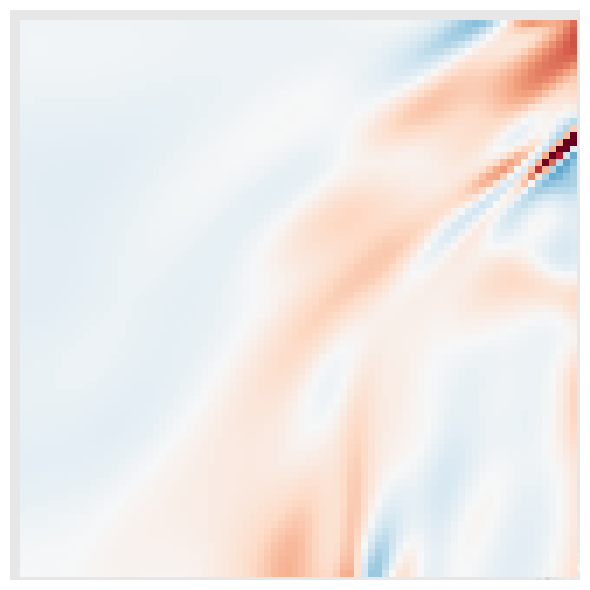

In [36]:
# Make 2D again
div = div_hr.reshape(X_zoom_hr.shape).detach().cpu().numpy()

X_modis_norm = (modis_ross[0] - x_min) / (x_max - x_min)
Y_modis_norm = (modis_ross[1] - y_min) / (y_max - y_min)

# normalise zoomed coords (2D)
X_zoom_hr_norm = (X_zoom_hr.values - x_min) / (x_max - x_min)
Y_zoom_hr_norm = (Y_zoom_hr.values - y_min) / (y_max - y_min)

fig, ax = plt.subplots(figsize = (8, 6))

# 1) MODIS background
ax.pcolormesh(
    X_modis_norm,
    Y_modis_norm,
    modis_ross[2],
    cmap = "gray",
    vmin = -30_000,
    vmax = 30_000,
    alpha = 0.4,
    zorder = 0,
)

# 2) Quiver overlay
ax.pcolormesh(
    X_zoom_hr_norm, 
    Y_zoom_hr_norm, 
    div,
    cmap = "RdBu",
    # different scale
    vmin = -30, 
    vmax = 30,
    zorder = 2)

# Cut off outside oflast vector
buffer = 0.005
ax.set_aspect("equal")
ax.set_xlim(x.min() - buffer, x.max() + buffer)
ax.set_ylim(y.min() - buffer, y.max() + buffer)
ax.set_axis_off()

fig.tight_layout()

fig.savefig("figures/div_helmholtz.png", dpi = 300, bbox_inches = "tight", pad_inches = 0)
plt.show()